# Introduction to Classification

## Objective
- Understand the concept of classification.
- Learn binary classification using a healthcare dataset.
- Build a classification model using Logistic Regression.
- Evaluate model performance using classification metrics.

## Dataset
Heart Disease Dataset from Kaggle.

## Problem Statement
Predict whether a patient has heart disease based on clinical attributes.

# Dataset Information

**Dataset Name:** Heart Disease Dataset

**Kaggle Link:**
https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

**Reason for Selection:**
This dataset is suitable for binary classification problems in healthcare.

**Credits:** Kaggle

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

In [2]:
# Load dataset
import pandas as pd
df = pd.read_csv("data/heart.csv")

# Display first 5 rows
print(df.head())

   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   52    1   0       125   212    0        1      168      0      1.0      2   
1   53    1   0       140   203    1        0      155      1      3.1      0   
2   70    1   0       145   174    0        1      125      1      2.6      0   
3   61    1   0       148   203    0        1      161      0      0.0      2   
4   62    0   0       138   294    1        1      106      0      1.9      1   

   ca  thal  target  
0   2     3       0  
1   0     3       0  
2   0     3       0  
3   1     3       0  
4   3     2       0  


In [3]:
import pandas as pd

df = pd.read_csv("data/heart.csv")

print(df.shape)

(1025, 14)


## Dataset Exploration

Before building the classification model, we explore the dataset structure, class distribution, and check for missing values.

In [4]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nClass Distribution:")
print(df['target'].value_counts())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
display(df.describe())

Dataset Shape: (1025, 14)

Column Names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target']

Class Distribution:
target
1    526
0    499
Name: count, dtype: int64

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Summary Statistics:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## Data Preprocessing

The dataset is divided into features and target variables. Then, the data is split into training and testing sets.

In [5]:
from sklearn.model_selection import train_test_split

# Features
X = df.drop('target', axis=1)

# Target
y = df['target']

# Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training Feature Shape:", X_train.shape)
print("Testing Feature Shape:", X_test.shape)
print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Feature Shape: (820, 13)
Testing Feature Shape: (205, 13)
Training Target Shape: (820,)
Testing Target Shape: (205,)


## Logistic Regression: From Scratch (NumPy)

In this section, Logistic Regression is implemented using NumPy without relying on scikit-learn.

In [6]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


c:\Users\harshitha\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [7]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [8]:
X_np = X.values

y_np = y.values

print("Feature Shape:", X_np.shape)

print("Target Shape:", y_np.shape)

Feature Shape: (1025, 13)
Target Shape: (1025,)


In [9]:
import numpy as np
weights = np.zeros(X_np.shape[1])

learning_rate = 0.001

epochs = 1000

In [10]:
for i in range(epochs):

    predictions = sigmoid(X_np @ weights)

    gradient = X_np.T @ (predictions - y_np) / len(y_np)

    weights -= learning_rate * gradient

In [11]:
predictions = sigmoid(X_np @ weights)

predictions = (predictions >= 0.5).astype(int)

accuracy = np.mean(predictions == y_np)

print("Scratch Accuracy:", round(accuracy, 4))

Scratch Accuracy: 0.6107


## Model Evaluation

After training the Logistic Regression model, we evaluate its performance using accuracy, confusion matrix, and classification report.

In [12]:
# Make predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy Score:", round(accuracy, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy Score: 0.8146

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.70      0.79       100
           1       0.76      0.92      0.84       105

    accuracy                           0.81       205
   macro avg       0.83      0.81      0.81       205
weighted avg       0.83      0.81      0.81       205



## Confusion Matrix

The confusion matrix summarizes the model's prediction performance by comparing actual and predicted class labels.

In [13]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[70 30]
 [ 8 97]]


## Target Class Distribution

This visualization shows the number of patients with and without heart disease.

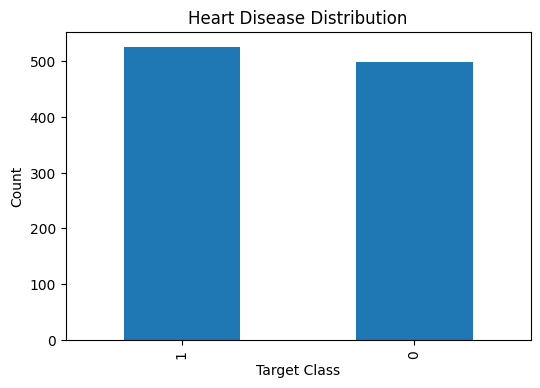

In [14]:
plt.figure(figsize=(6, 4))

df['target'].value_counts().plot(kind='bar')

plt.title('Heart Disease Distribution')
plt.xlabel('Target Class')
plt.ylabel('Count')

plt.show()

## Interview Corner

### Question:
What is the difference between classification and regression?

### Answer:
Regression predicts continuous numerical values, whereas classification predicts discrete categories or class labels.

## Accuracy Equation

Accuracy = (TP + TN)/(TP + TN + FP + FN)

Where:
- TP = True Positive
- TN = True Negative
- FP = False Positive
- FN = False Negative

### Significance
Measures how often the model predicts correctly.

## Key Takeaways

1. Classification is used to predict categorical outcomes.
2. Logistic Regression is a popular algorithm for binary classification.
3. Proper train-test splitting helps evaluate model performance fairly.
4. Accuracy, confusion matrix, and classification reports provide different perspectives on model quality.
5. Healthcare datasets are a common application of classification techniques.